# **Water Potability Classification**

## **Data Preparation**

### **Import Libraries**

In [1]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance

### **Display Dataset**

In [2]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1neWK64y6VMU7nvS1FNpA3aZ_76TYD5cw")
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


### **Identify Each Row and Column**

In [3]:
df.shape

(3276, 10)

### **Describing Data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### **Check for Missing Values**

In [6]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


### **Check for Outliers**

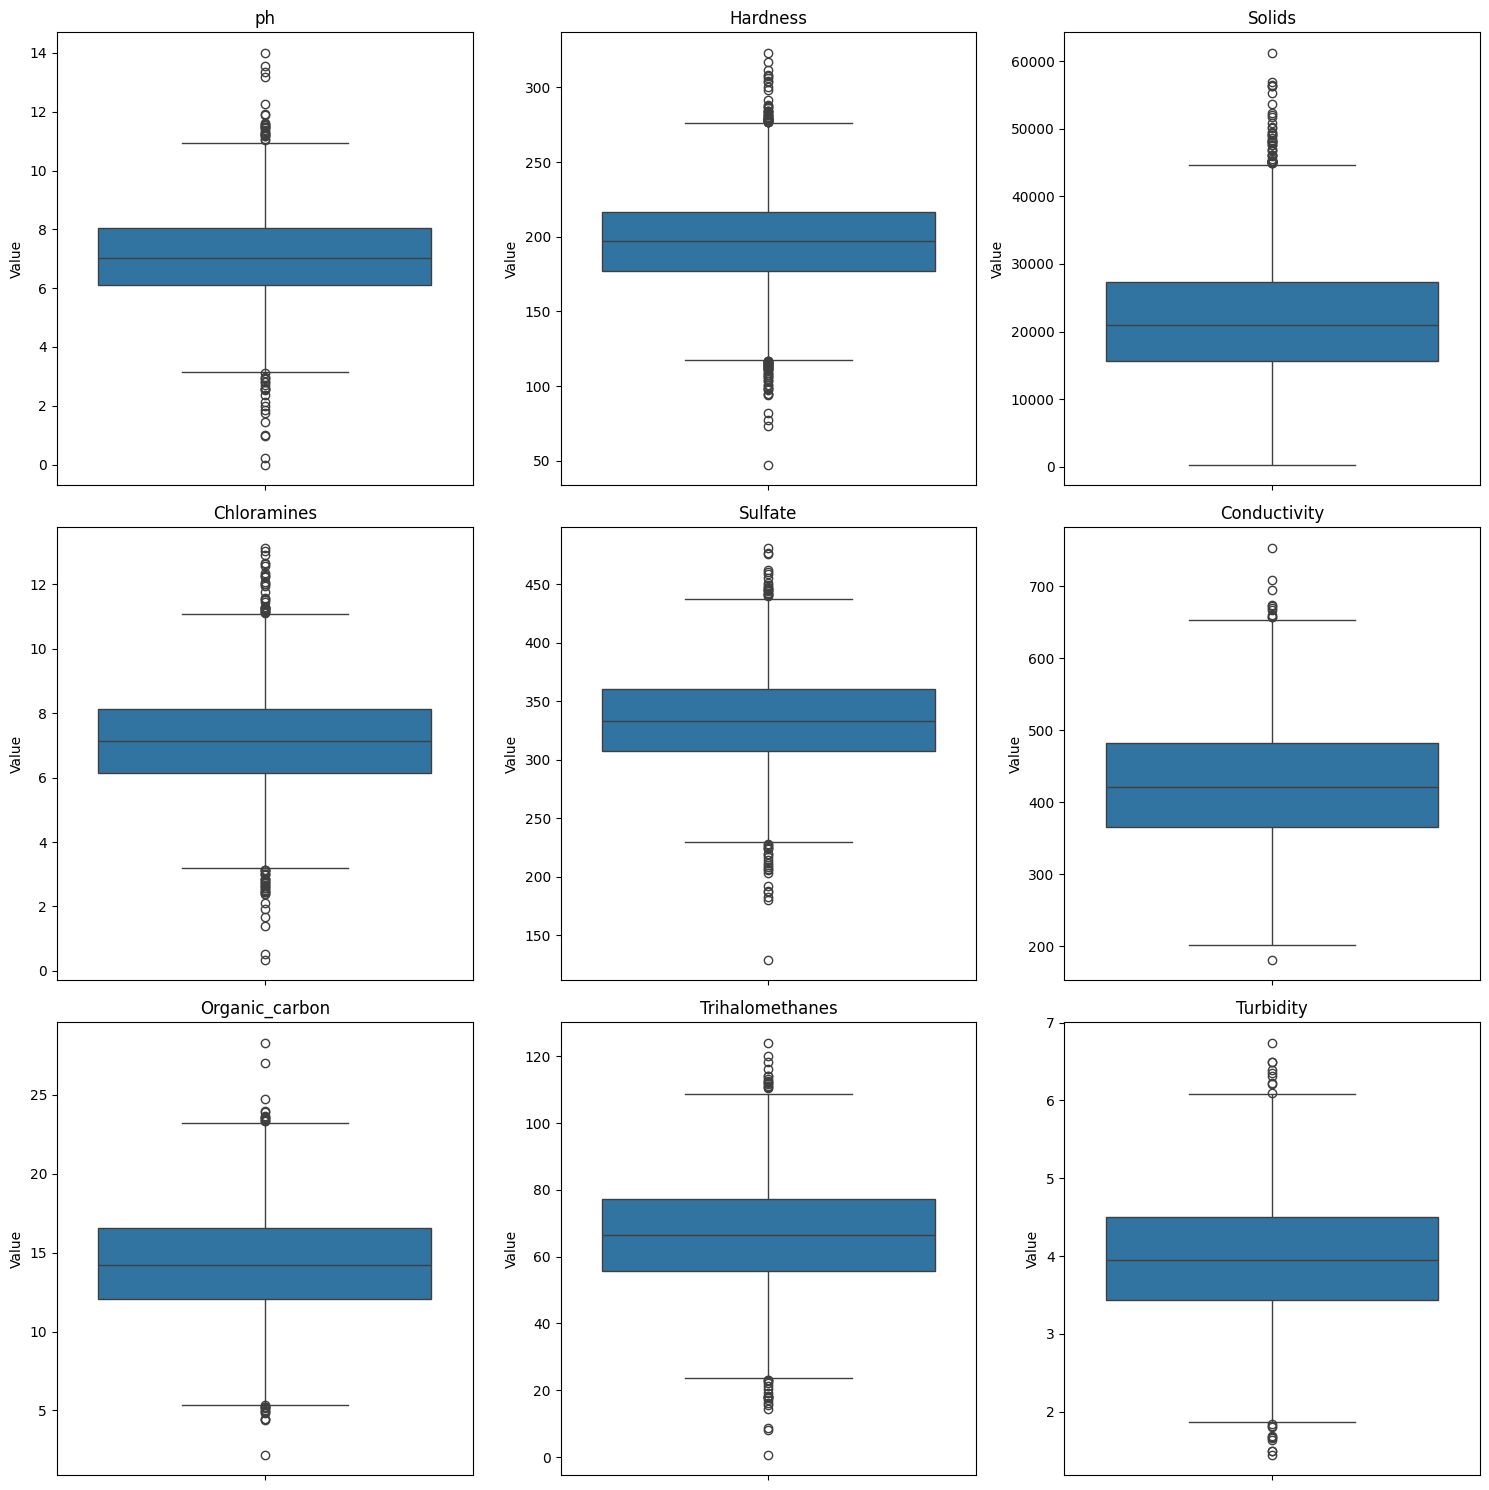


=== Number of Outliers per Column (IQR Method) ===
 ph: 46 outlier (1.40%)
 Hardness: 83 outlier (2.53%)
 Solids: 47 outlier (1.43%)
 Chloramines: 61 outlier (1.86%)
 Sulfate: 41 outlier (1.25%)
 Conductivity: 11 outlier (0.34%)
 Organic_carbon: 25 outlier (0.76%)
 Trihalomethanes: 33 outlier (1.01%)
 Turbidity: 19 outlier (0.58%)


In [7]:
feature_columns = df.columns.drop('Potability')
plt.figure(figsize=(15, 15))

for i, column in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'{column}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

print("\n=== Number of Outliers per Column (IQR Method) ===")

for column in feature_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    percentage = (outliers_count / len(df)) * 100
    print(f" {column}: {outliers_count} outlier ({percentage:.2f}%)")

### **Check for Duplicate Rows**

In [8]:
df.duplicated().sum()

np.int64(0)

### **Exploratory Data Analysis**

#### **Univariate Analysis**

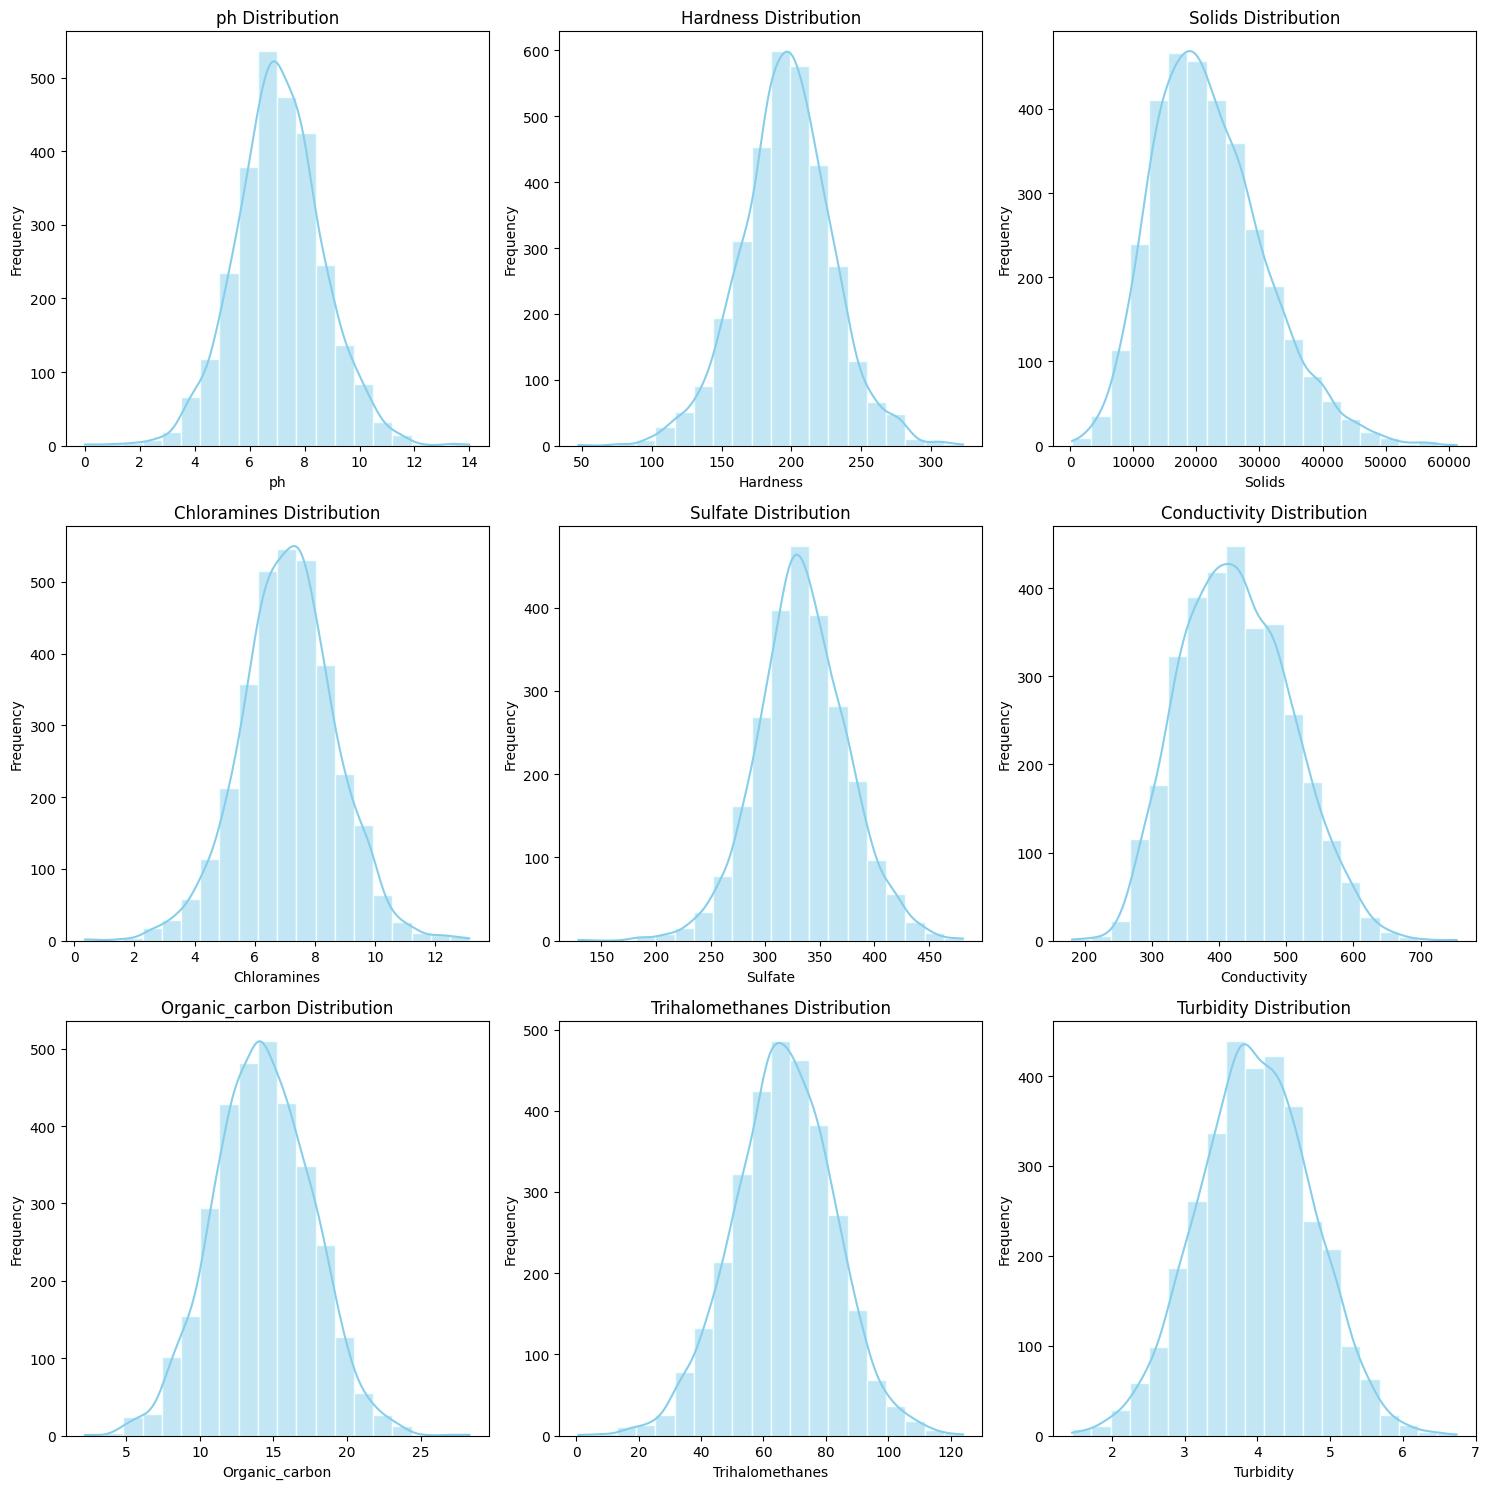

In [9]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue', edgecolor='azure')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### **Bivariate Analysis**

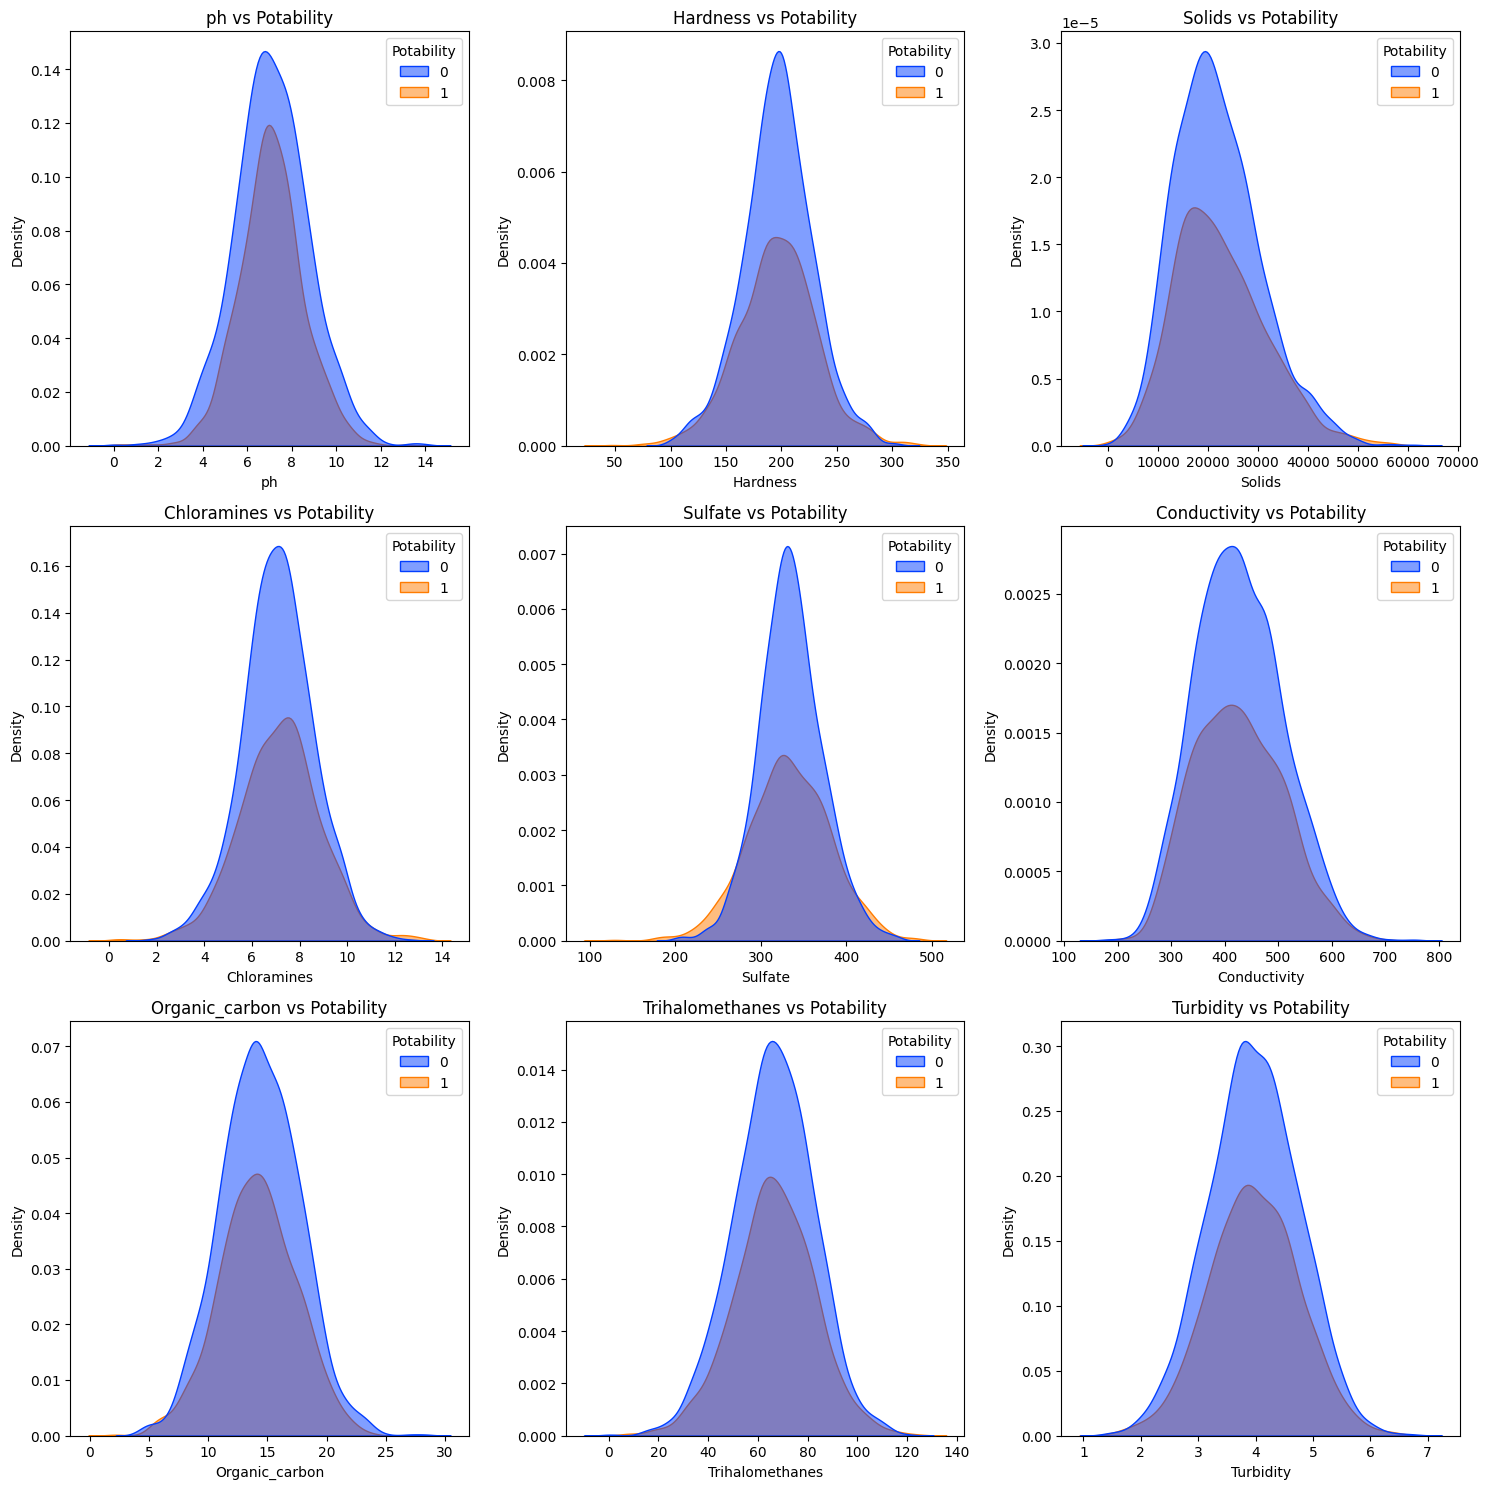

In [10]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue='Potability', fill=True, palette='bright', alpha=0.5)
    plt.title(f'{col} vs Potability')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

#### **Multivariate Analysis**

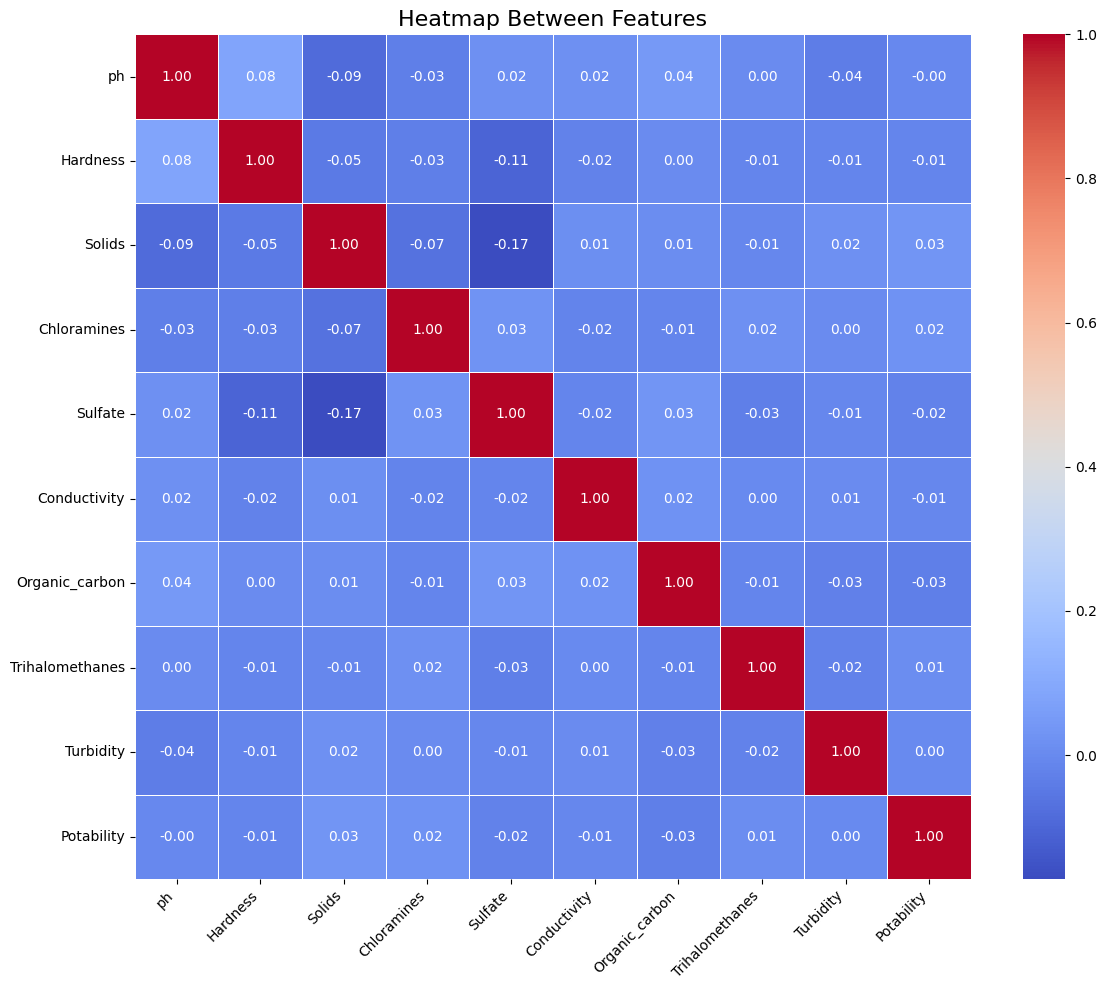

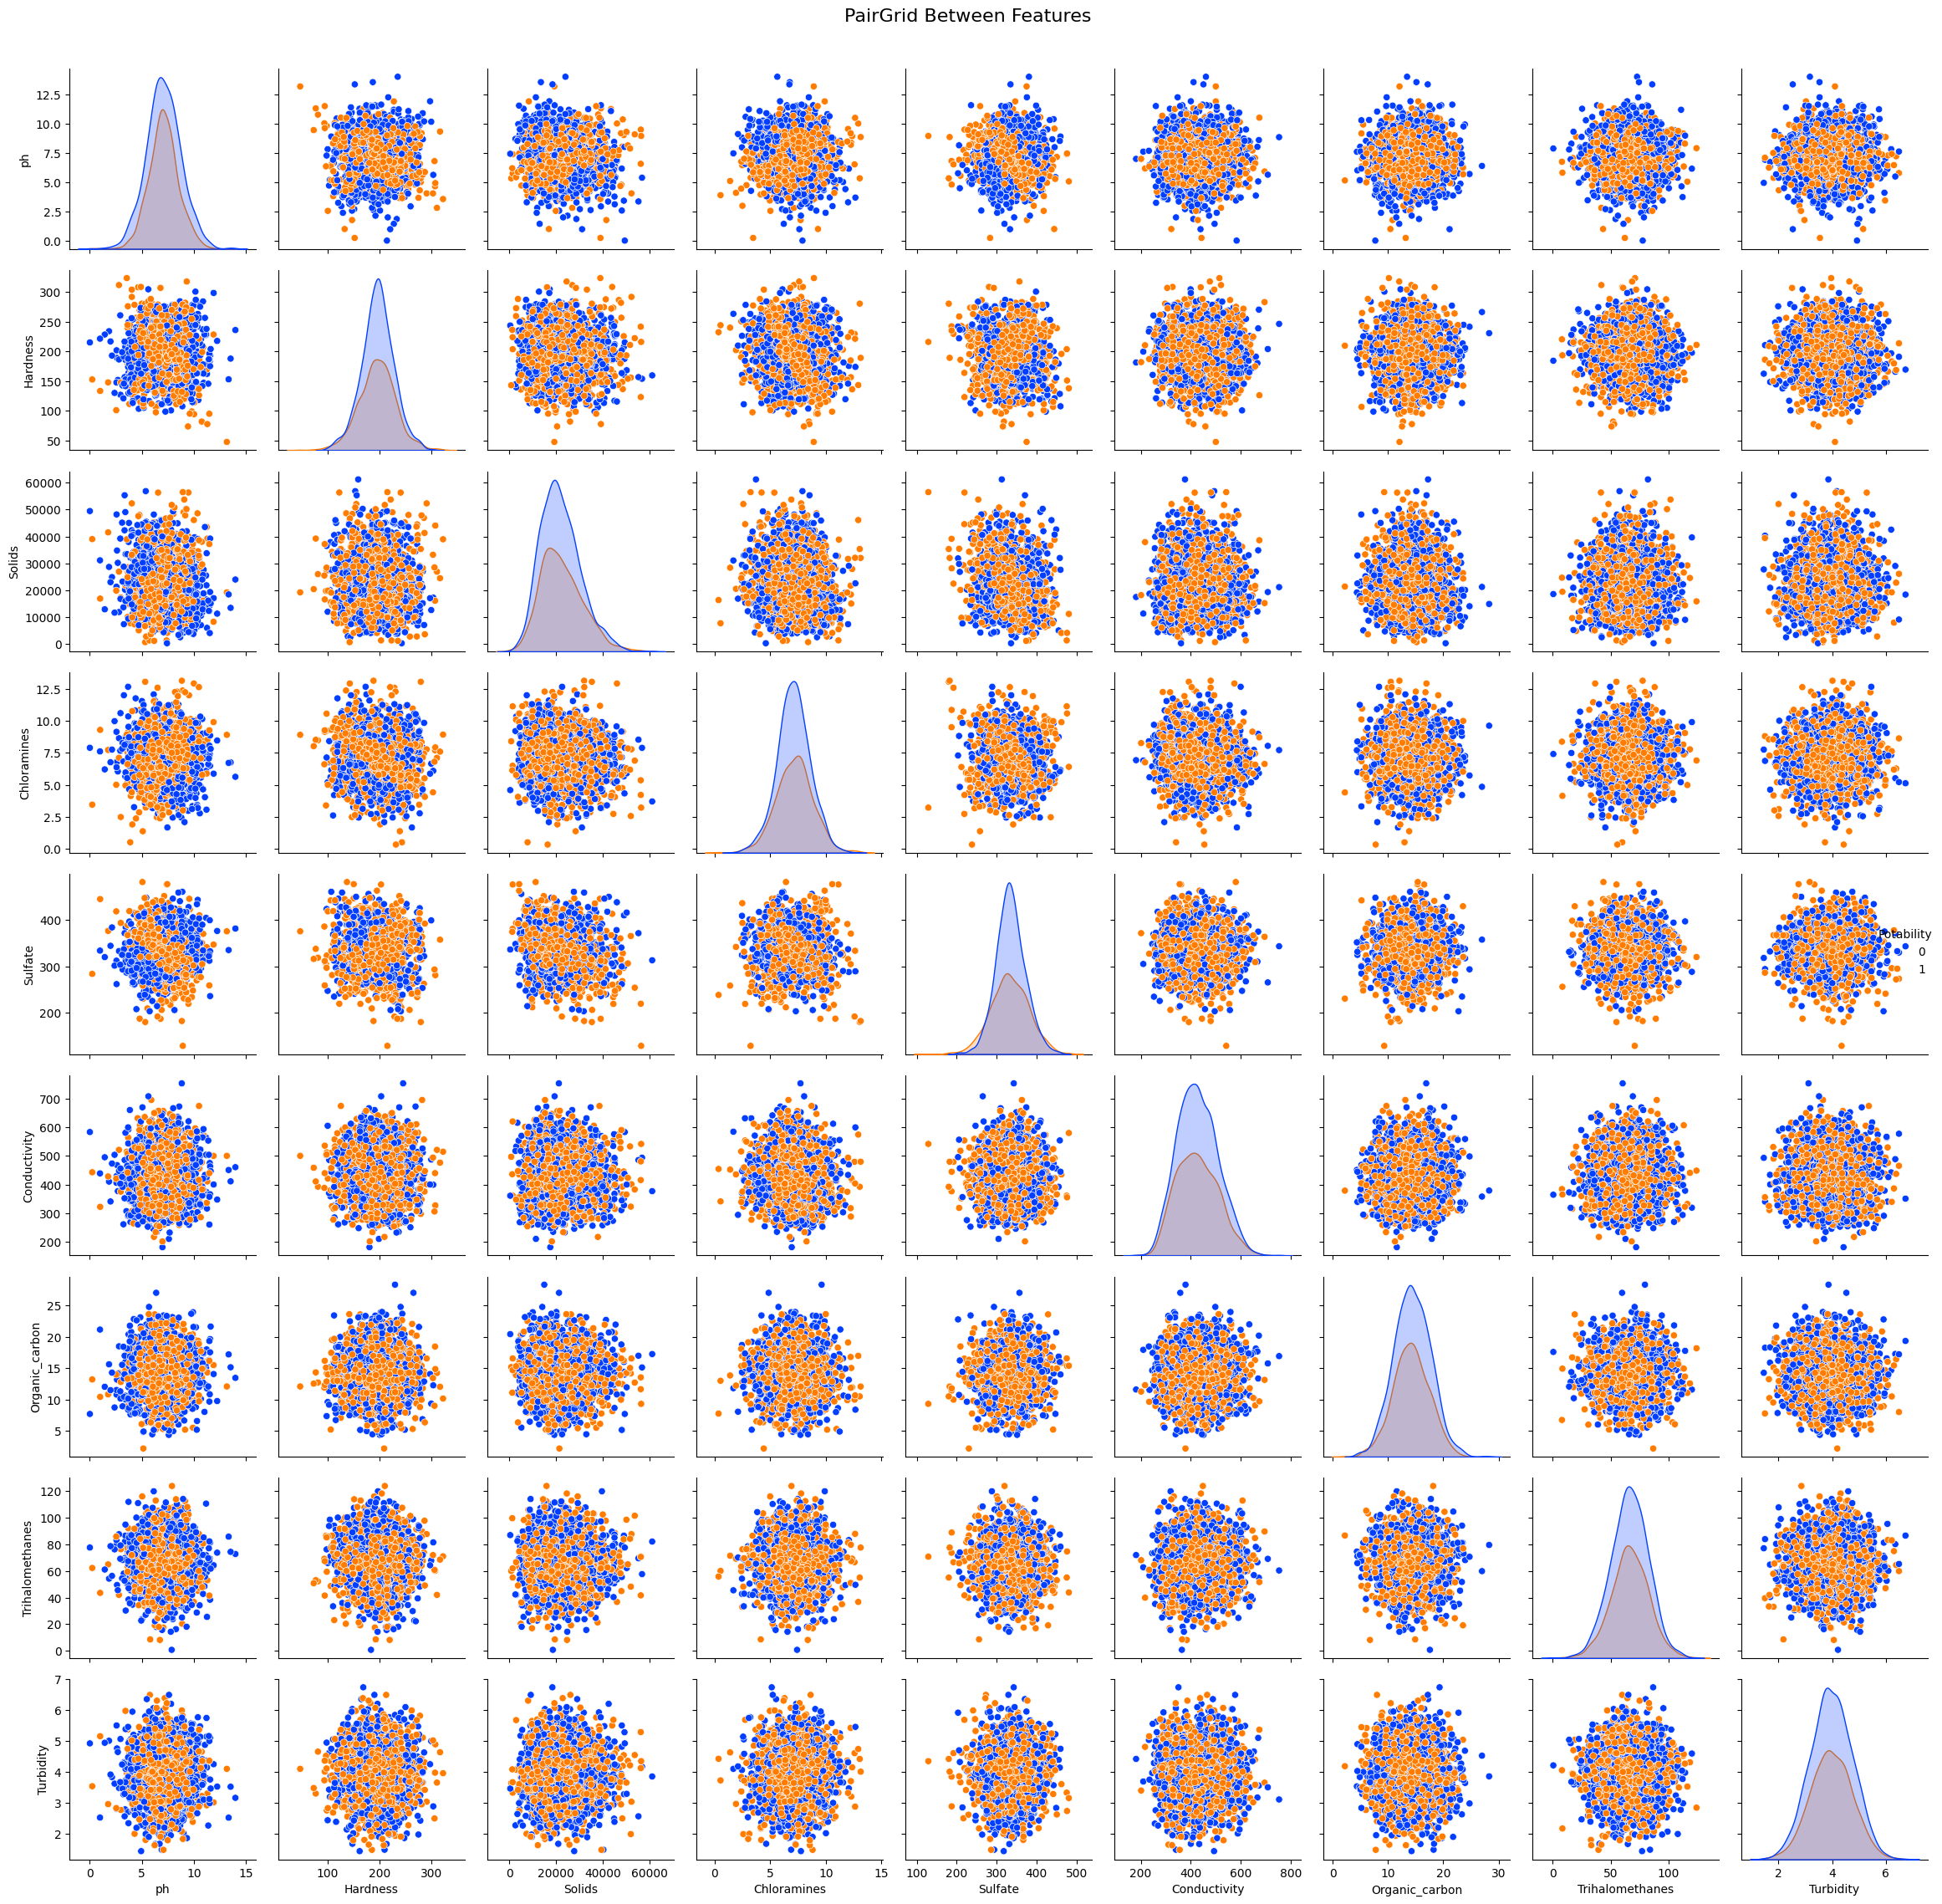

In [11]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Between Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n")

g = sns.pairplot(df, hue='Potability', palette='bright', vars=feature_columns)
g.fig.suptitle("PairGrid Between Features", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## **Data Preprocessing**

### **Identifying Mean, Median, Mode, and Skewness**

In [12]:
stat_summary = pd.DataFrame(index=df.columns)
stat_summary['Mean'] = df.mean()
stat_summary['Median'] = df.median()
stat_summary['Mode'] = df.mode().iloc[0]
stat_summary['Skewness'] = df.skew()
display(stat_summary)

,Mean,Median,Mode,Skewness
ph,7.080795,7.036752,0.000000,0.025630
Hardness,196.369496,196.967627,47.432000,-0.039342
Solids,22014.092526,20927.833607,320.942611,0.621634
Chloramines,7.122277,7.130299,0.352000,-0.012098
Sulfate,333.775777,333.073546,129.000000,-0.035947
Conductivity,426.205111,421.884968,181.483754,0.264490
Organic_carbon,14.284970,14.218338,2.200000,0.025533
Trihalomethanes,66.396293,66.622485,0.738000,-0.083031
Turbidity,3.966786,3.955028,1.450000,-0.007817
Potability,0.390110,0.000000,0.000000,0.450784


### **Handling Missing Values**

In [13]:
df_clean = df.copy()
missing_cols = ['ph', 'Sulfate', 'Trihalomethanes']

print("=== Handling Missing Values ===")

for col in missing_cols:
    mean_value = df_clean[col].mean()
    df_clean.fillna({col: mean_value}, inplace=True)
    print(f" Missing values ​​in the {col} column have been filled with Mean: {mean_value:.4f}")

=== Handling Missing Values ===
 Missing values ​​in the ph column have been filled with Mean: 7.0808
 Missing values ​​in the Sulfate column have been filled with Mean: 333.7758
 Missing values ​​in the Trihalomethanes column have been filled with Mean: 66.3963


#### **Check for Missing Values in a Clean Dataset**

In [14]:
print(df_clean.isnull().sum())
print("\n")

df_clean.info()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


### **Handling Outliers**

In [15]:
print("=== Handling Outliers ===")

feature_cols = df_clean.columns.drop('Potability')

for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    if outliers_before > 0:
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

        print(f" {col}: {outliers_before} outliers have been capped.")
        print(f" (Lower Bound: {lower_bound:.2f} & Upper Bound: {upper_bound:.2f})\n")

=== Handling Outliers ===
 ph: 142 outliers have been capped.
 (Lower Bound: 3.89 & Upper Bound: 10.26)

 Hardness: 83 outliers have been capped.
 (Lower Bound: 117.13 & Upper Bound: 276.39)

 Solids: 47 outliers have been capped.
 (Lower Bound: -1832.42 & Upper Bound: 44831.87)

 Chloramines: 61 outliers have been capped.
 (Lower Bound: 3.15 & Upper Bound: 11.10)

 Sulfate: 264 outliers have been capped.
 (Lower Bound: 267.16 & Upper Bound: 400.32)

 Conductivity: 11 outliers have been capped.
 (Lower Bound: 191.65 & Upper Bound: 655.88)

 Organic_carbon: 25 outliers have been capped.
 (Lower Bound: 5.33 & Upper Bound: 23.30)

 Trihalomethanes: 54 outliers have been capped.
 (Lower Bound: 26.62 & Upper Bound: 106.70)

 Turbidity: 19 outliers have been capped.
 (Lower Bound: 1.85 & Upper Bound: 6.09)



#### **Check for Outliers in a Clean Dataset**

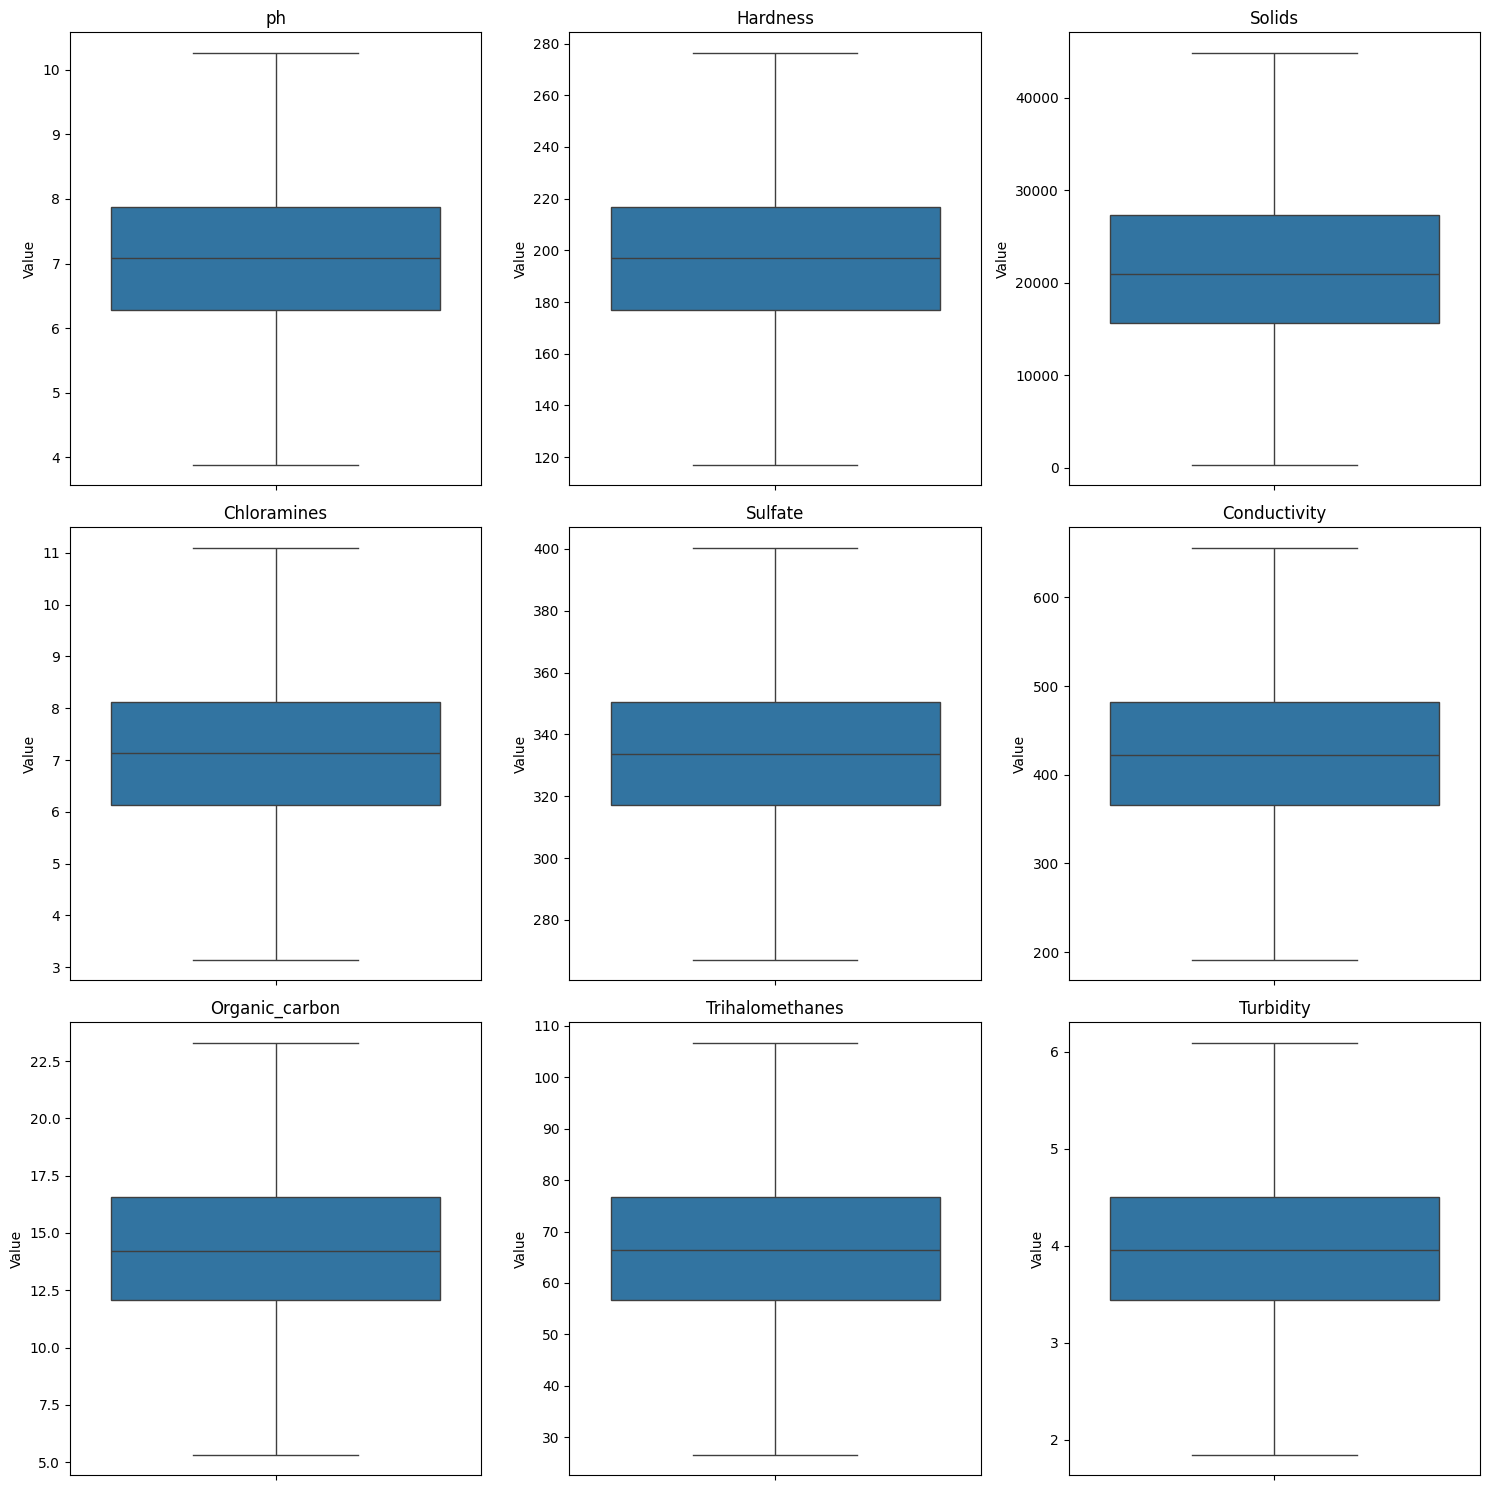


=== Number of Outliers per Column in a Clean Dataset (IQR Method) ===
 ph: 0 outlier (0.00%)
 Hardness: 0 outlier (0.00%)
 Solids: 0 outlier (0.00%)
 Chloramines: 0 outlier (0.00%)
 Sulfate: 0 outlier (0.00%)
 Conductivity: 0 outlier (0.00%)
 Organic_carbon: 0 outlier (0.00%)
 Trihalomethanes: 0 outlier (0.00%)
 Turbidity: 0 outlier (0.00%)


In [16]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[column])
    plt.title(f'{column}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

print("\n=== Number of Outliers per Column in a Clean Dataset (IQR Method) ===")

for column in feature_cols:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)).sum()
    percentage = (outliers_count / len(df_clean)) * 100
    print(f" {column}: {outliers_count} outlier ({percentage:.2f}%)")

### **Basic Statistics**

In [17]:
numeric_features = df_clean.drop('Potability', axis=1)

stats_df = pd.DataFrame(index=numeric_features.columns)
stats_df['Mean'] = numeric_features.mean()
stats_df['Median'] = numeric_features.median()
stats_df['Mode'] = numeric_features.mode().iloc[0]
stats_df['Min'] = numeric_features.min()
stats_df['Max'] = numeric_features.max()
stats_df['Range'] = numeric_features.max() - numeric_features.min()
stats_df['Variance'] = numeric_features.var()
stats_df['Std Dev'] = numeric_features.std()
stats_df['Skewness'] = numeric_features.skew()
stats_df['Kurtosis'] = numeric_features.kurt()

display(stats_df.round(4))

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev,Skewness,Kurtosis
ph,7.0799,7.0808,7.0808,3.8891,10.2586,6.3695,1.909800e+00,1.3820,0.0402,0.0865
Hardness,196.3924,196.9676,117.1252,117.1252,276.3928,159.2677,1.025100e+03,32.0172,-0.0250,0.0470
Solids,21957.1122,20927.8336,44831.8699,320.9426,44831.8699,44510.9273,7.383656e+07,8592.8204,0.4846,-0.0954
Chloramines,7.1218,7.1303,3.1462,3.1462,11.0961,7.9499,2.384300e+00,1.5441,-0.0179,0.0033
Sulfate,333.7887,333.7758,333.7758,267.1580,400.3224,133.1645,1.009206e+03,31.7680,0.0397,-0.0471
Conductivity,426.1300,421.8850,655.8791,191.6476,655.8791,464.2316,6.490581e+03,80.5641,0.2406,-0.3774
Organic_carbon,14.2835,14.2183,5.3280,5.3280,23.2954,17.9674,1.081340e+01,3.2884,0.0087,-0.1315
Trihalomethanes,66.4204,66.3963,66.3963,26.6192,106.6950,80.0758,2.398517e+02,15.4871,-0.0496,0.0069
Turbidity,3.9666,3.9550,1.8488,1.8488,6.0912,4.2424,6.028000e-01,0.7764,-0.0144,-0.1837


### **Export Clean Dataset**

In [18]:
df_clean.to_csv('water_potability_main_data.csv', index=False)

### **Data Normalization**

In [19]:
x = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

scaler = StandardScaler()

x_scaled_array = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled_array, columns=x.columns)

display(x_scaled.head())
print("\n")
display(x_scaled.describe().round(2))

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.000612,0.265461,-0.135691,0.115564,1.093335,1.715401,-1.187299,1.328436,-1.292657
1,-2.309292,-2.091993,-0.387249,-0.315144,-0.000406,2.070162,0.272685,-0.651695,0.687944
2,0.737603,0.869786,-0.238325,1.395235,-0.000406,-0.093403,0.786278,-0.000022,-1.173116
3,0.895116,0.561689,0.007136,0.607257,0.727178,-0.780410,1.263149,2.190618,0.852978
4,1.456334,-0.477657,-0.463030,-0.372561,-0.744666,-0.344116,-0.828861,-2.222985,0.139720


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.31,-2.48,-2.52,-2.58,-2.10,-2.91,-2.72,-2.57,-2.73
25%,-0.58,-0.61,-0.73,-0.64,-0.53,-0.75,-0.67,-0.63,-0.68
50%,0.00,0.02,-0.12,0.01,-0.00,-0.05,-0.02,-0.00,-0.01
75%,0.57,0.63,0.63,0.64,0.52,0.69,0.69,0.66,0.69
max,2.30,2.50,2.66,2.57,2.09,2.85,2.74,2.60,2.74


### **Export Normalized Dataset**

In [20]:
df_normalized = pd.concat([x_scaled, y.reset_index(drop=True)], axis=1)
df_normalized.to_csv('water_potability_normalized.csv', index=False)

## **Data Modeling**

### **Splitting Data**

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("=== Split Data Results ===")
print(f" Original Data      : {x_scaled.shape[0]} rows")
print(f" Data Training (80%): {x_train.shape[0]} rows")
print(f" Data Testing (20%) : {x_test.shape[0]} rows")

print("\n=== Dimension Data ===")
print(f" x_train: {x_train.shape}")
print(f" y_train: {y_train.shape}")
print(f" x_test : {x_test.shape}")
print(f" y_test : {y_test.shape}")

=== Split Data Results ===
 Original Data      : 3276 rows
 Data Training (80%): 2620 rows
 Data Testing (20%) : 656 rows

=== Dimension Data ===
 x_train: (2620, 9)
 y_train: (2620,)
 x_test : (656, 9)
 y_test : (656,)


### **Training Models**

#### **Random Forest**

In [22]:
start_time = time.time()

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

end_time = time.time()
print(f"Random Forest model successfully trained in {end_time - start_time:.2f} seconds.")

Random Forest model successfully trained in 1.79 seconds.


#### **Support Vector Machine (SVM)**

In [23]:
start_time = time.time()

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(x_train, y_train)

end_time = time.time()
print(f"SVM model successfully trained in {end_time - start_time:.2f} seconds.")

SVM model successfully trained in 2.08 seconds.


## **Models Evaluation**

### **Classification Report**

In [24]:
def evaluate_model(model, model_name, x_test, y_test):
    y_pred = model.predict(x_test)

    print(f"=== {model_name} ===")
    print(f" Accuracy Test Set: {accuracy_score(y_test, y_pred):.4f}")
    print("\n Classification Report:")
    print(classification_report(y_test, y_pred))

    return confusion_matrix(y_test, y_pred)

cm_rf = evaluate_model(rf_model, "Random Forest", x_test, y_test)
print("\n")
cm_svm = evaluate_model(svm_model, "SVM", x_test, y_test)

=== Random Forest ===
 Accuracy Test Set: 0.6662

 Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.32      0.43       256

    accuracy                           0.67       656
   macro avg       0.66      0.60      0.60       656
weighted avg       0.66      0.67      0.63       656



=== SVM ===
 Accuracy Test Set: 0.6616

 Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.91      0.77       400
           1       0.66      0.28      0.39       256

    accuracy                           0.66       656
   macro avg       0.66      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656



### **Confusion Matrix**

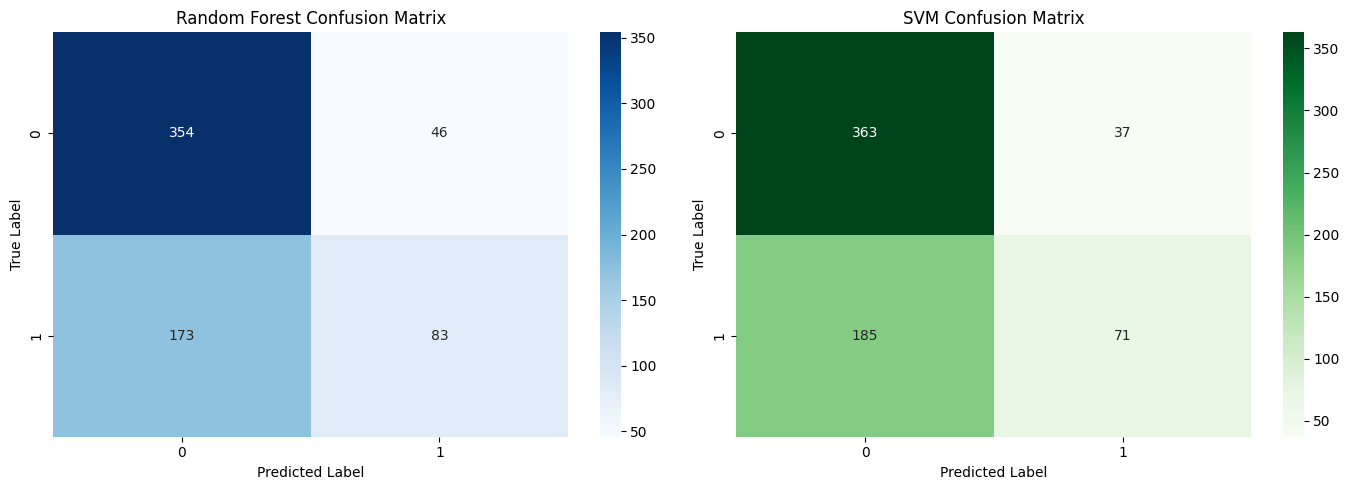

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('SVM Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### **Cross Validation**

In [26]:
def run_cv(model, model_name, x, y):
    scores = cross_val_score(model, x, y, cv=5, scoring='accuracy')

    print(f"=== {model_name} (5-Fold CV) ===")
    print(f" Score per Fold    : {scores}")
    print(f" Average Score     : {scores.mean():.4f}")
    print(f" Standard Deviation: {scores.std():.4f}")

run_cv(rf_model, "Random Forest", x_scaled, y)
print("\n")
run_cv(svm_model, "SVM", x_scaled, y)

=== Random Forest (5-Fold CV) ===
 Score per Fold    : [0.61432927 0.64885496 0.65954198 0.60305344 0.67328244]
 Average Score     : 0.6398
 Standard Deviation: 0.0268


=== SVM (5-Fold CV) ===
 Score per Fold    : [0.60518293 0.6610687  0.68091603 0.61526718 0.67938931]
 Average Score     : 0.6484
 Standard Deviation: 0.0321


### **Identifying Overfitting and Underfitting**

In [27]:
def check_fit(model, model_name, x_train, y_train, x_test, y_test):
    train_acc = model.score(x_train, y_train)
    test_acc = model.score(x_test, y_test)
    gap = train_acc - test_acc

    print(f"=== {model_name} ===")
    print(f" Accuracy Training: {train_acc*100:.2f}%")
    print(f" Accuracy Testing : {test_acc*100:.2f}%")
    print(f" Gap (Difference) : {gap*100:.2f}%")

    if gap > 0.10:
        print(" Status: OVERFITTING")
    elif gap < 0.03:
        if train_acc < 0.60:
            print("Status: UNDERFITTING")
        else:
            print("Status: GOOD FIT")
    else:
        print(" Status: GOOD FIT")

check_fit(rf_model, "Random Forest", x_train, y_train, x_test, y_test)
print("\n")
check_fit(svm_model, "SVM", x_train, y_train, x_test, y_test)

=== Random Forest ===
 Accuracy Training: 100.00%
 Accuracy Testing : 66.62%
 Gap (Difference) : 33.38%
 Status: OVERFITTING


=== SVM ===
 Accuracy Training: 74.08%
 Accuracy Testing : 66.16%
 Gap (Difference) : 7.93%
 Status: GOOD FIT


### **Feature Importance**

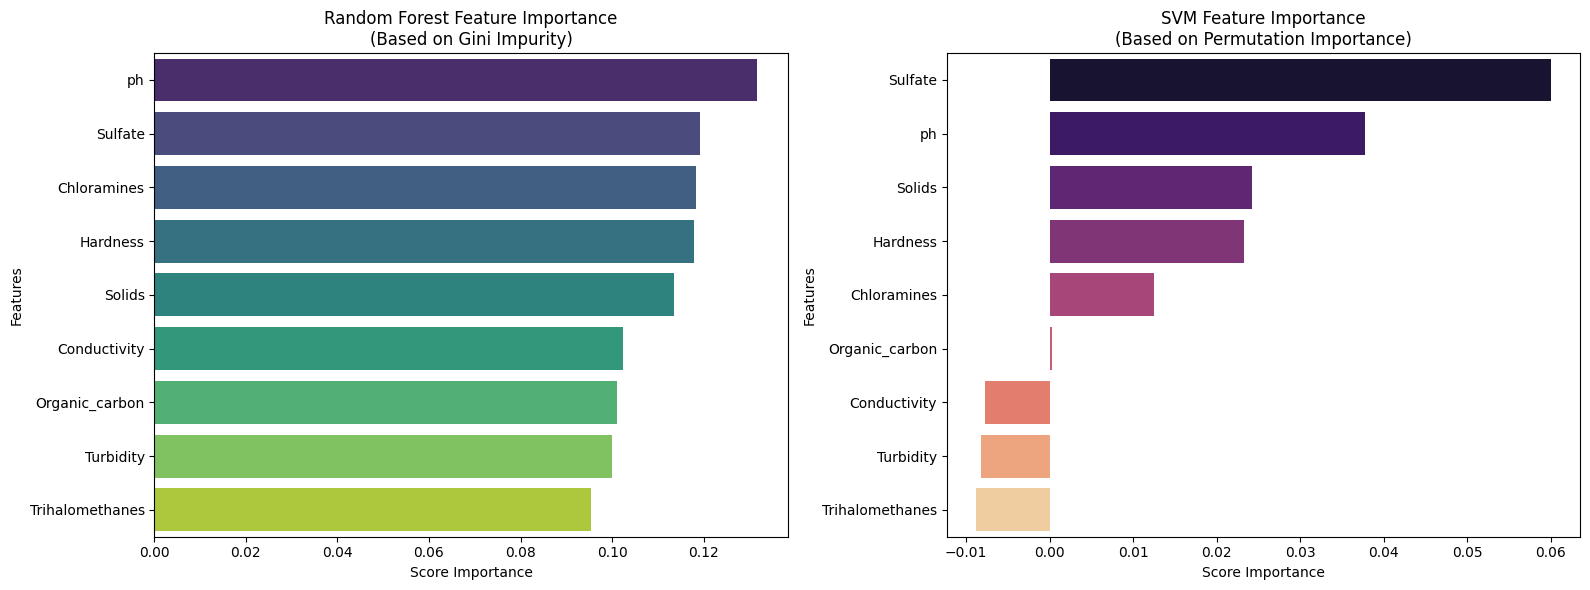

In [28]:
feature_names = x_train.columns

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
rf_importances = rf_importances.sort_values(ascending=False)

perm_importance = permutation_importance(svm_model, x_test, y_test, n_repeats=10, random_state=42)
svm_importances = pd.Series(perm_importance.importances_mean, index=feature_names)
svm_importances = svm_importances.sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=rf_importances.values, y=rf_importances.index, hue=rf_importances.index, palette='viridis', ax=ax[0])
ax[0].set_title('Random Forest Feature Importance\n(Based on Gini Impurity)')
ax[0].set_xlabel('Score Importance')
ax[0].set_ylabel('Features')

sns.barplot(x=svm_importances.values, y=svm_importances.index, hue=svm_importances.index, palette='magma', ax=ax[1])
ax[1].set_title('SVM Feature Importance\n(Based on Permutation Importance)')
ax[1].set_xlabel('Score Importance')
ax[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

### **Hyperparameter Tuning**

#### **Random Forest Tuning**

In [29]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [15, 20],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=param_grid_rf,
                       scoring='accuracy',
                       cv=5,
                       n_jobs=-1,
                       verbose=1)
grid_rf.fit(x_train, y_train)

best_rf_model = grid_rf.best_estimator_
print(f"\n Random Forest Best Parameters: {grid_rf.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Random Forest Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 15, 'n_estimators': 200}


#### **SVM Tuning**

In [30]:
param_grid_svm = {
    'C': [0.01, 0.1, 0.5, 0.8, 1.0],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(estimator=SVC(probability=True, random_state=42),
                        param_grid=param_grid_svm,
                        scoring='accuracy',
                        cv=5,
                        n_jobs=-1,
                        verbose=1)
grid_svm.fit(x_train, y_train)

best_svm_model = grid_svm.best_estimator_
print(f"\nSVM Best Parameters: {grid_svm.best_params_}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

SVM Best Parameters: {'C': 0.8, 'gamma': 'scale', 'kernel': 'rbf'}


## **Final Evaluation**

### **Classification Report (Tuned Models)**

In [31]:
def tuned_evaluation(model, model_name, x_test, y_test):
    y_pred = model.predict(x_test)

    print(f"=== {model_name} (TUNED) ===")
    print(f" Accuracy Test Set: {accuracy_score(y_test, y_pred):.4f}")
    print("\n Classification Report:")
    print(classification_report(y_test, y_pred))

    return confusion_matrix(y_test, y_pred)

cm_rf_tuned = tuned_evaluation(best_rf_model, "Random Forest", x_test, y_test)
print("\n")
cm_svm_tuned = tuned_evaluation(best_svm_model, "SVM", x_test, y_test)

=== Random Forest (TUNED) ===
 Accuracy Test Set: 0.6555

 Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.95      0.77       400
           1       0.71      0.20      0.31       256

    accuracy                           0.66       656
   macro avg       0.68      0.57      0.54       656
weighted avg       0.67      0.66      0.59       656



=== SVM (TUNED) ===
 Accuracy Test Set: 0.6646

 Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.92      0.77       400
           1       0.67      0.27      0.39       256

    accuracy                           0.66       656
   macro avg       0.67      0.59      0.58       656
weighted avg       0.67      0.66      0.62       656



### **Confusion Matrix (Tuned Models)**

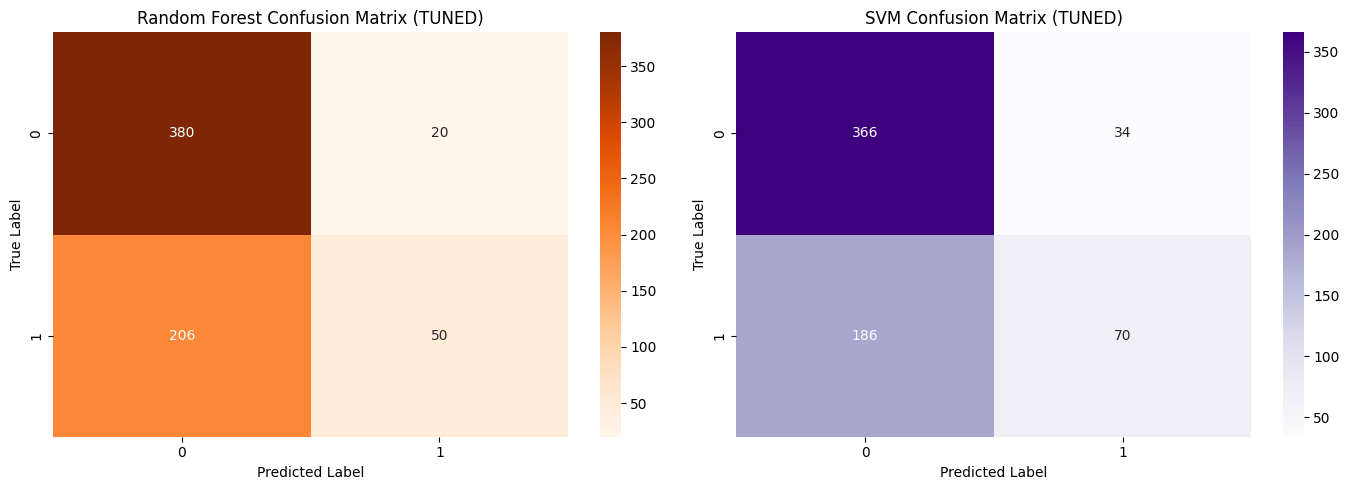

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix (TUNED)')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

sns.heatmap(cm_svm_tuned, annot=True, fmt='d', cmap='Purples', ax=ax[1])
ax[1].set_title('SVM Confusion Matrix (TUNED)')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### **Cross Validation (Tuned Models)**

In [33]:
def run_tuned_cv(model, model_name, x, y):
    scores = cross_val_score(model, x, y, cv=5, scoring='accuracy')

    print(f"=== {model_name} (5-Fold CV) (TUNED) ===")
    print(f" Score per Fold    : {scores}")
    print(f" Average Score     : {scores.mean():.4f}")
    print(f" Standard Deviation: {scores.std():.4f}")

run_tuned_cv(best_rf_model, "Random Forest", x_train, y_train)
print("\n")
run_tuned_cv(best_svm_model, "SVM", x_train, y_train)

=== Random Forest (5-Fold CV) (TUNED) ===
 Score per Fold    : [0.65839695 0.65648855 0.64694656 0.65458015 0.64885496]
 Average Score     : 0.6531
 Standard Deviation: 0.0044


=== SVM (5-Fold CV) (TUNED) ===
 Score per Fold    : [0.66603053 0.68320611 0.67748092 0.6889313  0.67366412]
 Average Score     : 0.6779
 Standard Deviation: 0.0079


### **Identifying Overfitting and Underfitting (Tuned Models)**

In [34]:
def check_final_fit(model, model_name, x_train, y_train, x_test, y_test):
    train_acc = model.score(x_train, y_train)
    test_acc = model.score(x_test, y_test)
    gap = train_acc - test_acc

    print(f"=== {model_name} (TUNED) ===")
    print(f" Accuracy Training: {train_acc*100:.2f}%")
    print(f" Accuracy Testing : {test_acc*100:.2f}%")
    print(f" Gap (Difference) : {gap*100:.2f}%")

    if gap > 0.10:
        print("Status: OVERFITTING")
    elif gap < 0.03:
        if train_acc < 0.60:
            print("Status: UNDERFITTING")
        else:
            print("Status: GOOD FIT")
    else:
        print("Status: GOOD FIT")

check_final_fit(best_rf_model, "Random Forest", x_train, y_train, x_test, y_test)
print("\n")
check_final_fit(best_svm_model, "SVM", x_train, y_train, x_test, y_test)

=== Random Forest (TUNED) ===
 Accuracy Training: 72.94%
 Accuracy Testing : 65.55%
 Gap (Difference) : 7.39%
Status: GOOD FIT


=== SVM (TUNED) ===
 Accuracy Training: 72.82%
 Accuracy Testing : 66.46%
 Gap (Difference) : 6.36%
Status: GOOD FIT


### **Feature Importance (Tuned Models)**

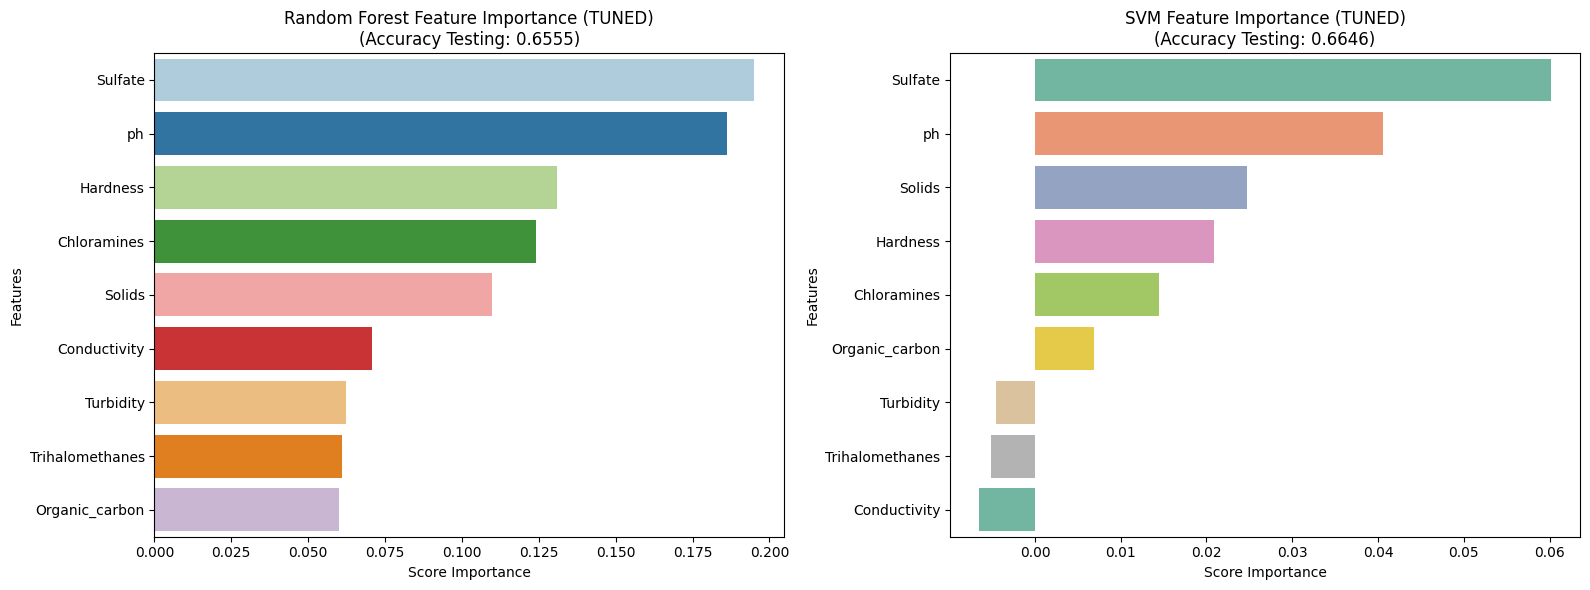

In [35]:
rf_tuned_imp = pd.Series(best_rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

result_svm = permutation_importance(best_svm_model, x_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
svm_tuned_imp = pd.Series(result_svm.importances_mean, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=rf_tuned_imp.values, y=rf_tuned_imp.index, hue=rf_tuned_imp.index, palette='Paired', ax=ax[0])
ax[0].set_title(f'Random Forest Feature Importance (TUNED)\n(Accuracy Testing: {best_rf_model.score(x_test, y_test):.4f})')
ax[0].set_xlabel('Score Importance')
ax[0].set_ylabel('Features')

sns.barplot(x=svm_tuned_imp.values, y=svm_tuned_imp.index, hue=svm_tuned_imp.index, palette='Set2', ax=ax[1])
ax[1].set_title(f'SVM Feature Importance (TUNED)\n(Accuracy Testing: {best_svm_model.score(x_test, y_test):.4f})')
ax[1].set_xlabel('Score Importance')
ax[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

### **Export Models**

#### **Scaler**

In [36]:
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

#### **Random Forest**

In [37]:
joblib.dump(best_rf_model, 'rf_model.joblib')

['rf_model.joblib']

#### **SVM**

In [38]:
joblib.dump(best_svm_model, 'svm_model.joblib')

['svm_model.joblib']